In [1]:
import numpy as np   
import pandas as pd   
import matplotlib.pyplot as plt   
import seaborn as sns   
from scipy import stats
import warnings
import pickle   


from os import path

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn import metrics
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report

from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

warnings.simplefilter('ignore')

pd.set_option('display.max_columns', None)


In [2]:
df_multi = pd.read_csv('multi_data.csv')


In [3]:
df_multi = df_multi.loc[:, ~df_multi.columns.str.contains('^Unnamed')]


In [4]:
le_2 = np.load("lebal_2_classes.npy",allow_pickle=True)

print(le_2)


['analysis' 'backdoor' 'dos' 'exploits' 'fuzzers' 'generic' 'normal'
 'reconnaissance' 'worms']


In [5]:
df_multi

,srcip,sttl,dttl,tcprtt,synack,ackdat,ct_state_ttl,label
0,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,6
1,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,6
2,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,6
3,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,6
4,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,6
...,...,...,...,...,...,...,...,...
890232,0.299907,0.000000,0.114173,0.000388,0.000889,0.000081,0.0,6
890233,0.299907,0.000000,0.114173,0.000449,0.001018,0.000098,0.0,6
890234,0.299907,0.000000,0.114173,0.000408,0.000899,0.000098,0.0,6
890235,0.299907,0.000000,0.114173,0.000456,0.001039,0.000098,0.0,6


# Balancing Dataset (With SMOTE Method)

In [6]:
from collections import Counter
from imblearn.over_sampling import SMOTE

In [7]:
# Splitting features and target
X = df_multi.drop(columns=['label'])
y = df_multi['label']

# Apply SMOTE or another method you used earlier
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


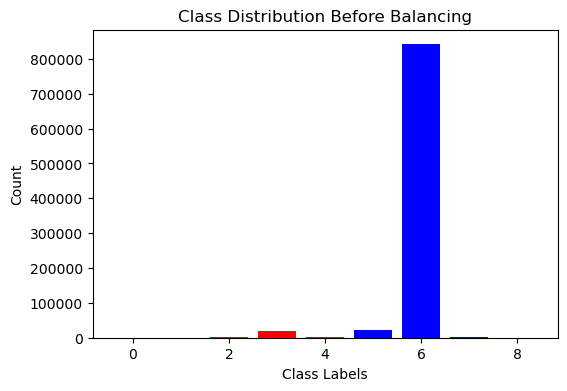

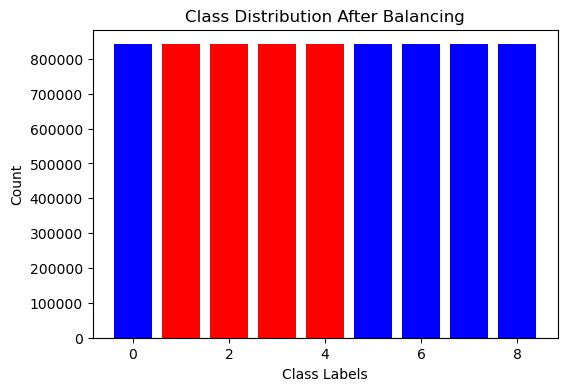

In [8]:
# Get Class distribution before balancing
class_counts_before = Counter(df_multi['label'])

# class distribution before balancing
plt.figure(figsize=(6, 4))
plt.bar(class_counts_before.keys(), class_counts_before.values(), color=['blue', 'red'])
plt.xlabel("Class Labels")
plt.ylabel("Count")
plt.title("Class Distribution Before Balancing")
plt.show()

# Get new class distribution after balancing
class_counts_after = Counter(y_resampled)

# class distribution after balancing
plt.figure(figsize=(6, 4))
plt.bar(class_counts_after.keys(), class_counts_after.values(), color=['blue', 'red'])
plt.xlabel("Class Labels")
plt.ylabel("Count")
plt.title("Class Distribution After Balancing")
plt.show()

In [9]:
df_balanced = pd.DataFrame(X_resampled, columns=X.columns)
df_balanced['label'] = y_resampled  # Add back the target column
df_bin = df_balanced  # Replace original dataset if needed


In [10]:
df_bin['label'].value_counts()


label
6    841694
3    841694
7    841694
2    841694
5    841694
4    841694
8    841694
1    841694
0    841694
Name: count, dtype: int64

In [11]:
X = df_bin.drop(columns=['label'],axis=1)
Y = df_bin['label']

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.3, random_state=50)
     

## Logistic Regression

In [13]:
 
lr_multi = LogisticRegression()
lr_multi.fit(X_train, y_train)


y_pred = lr_multi.predict(X_test)


cls_report = classification_report(y_test, y_pred, target_names=le_2)
print(cls_report)


print("Accuracy - ", accuracy_score(y_test, y_pred) * 100)


                precision    recall  f1-score   support

      analysis       0.52      0.83      0.64    252395
      backdoor       0.00      0.00      0.00    252421
           dos       0.35      0.20      0.26    252601
      exploits       0.31      0.15      0.20    252379
       fuzzers       0.34      0.49      0.40    252926
       generic       0.86      0.90      0.88    253124
        normal       1.00      0.99      1.00    252674
reconnaissance       0.29      0.49      0.36    252385
         worms       0.25      0.30      0.27    251669

      accuracy                           0.48   2272574
     macro avg       0.44      0.48      0.45   2272574
  weighted avg       0.44      0.48      0.45   2272574

Accuracy -  48.4076646129015


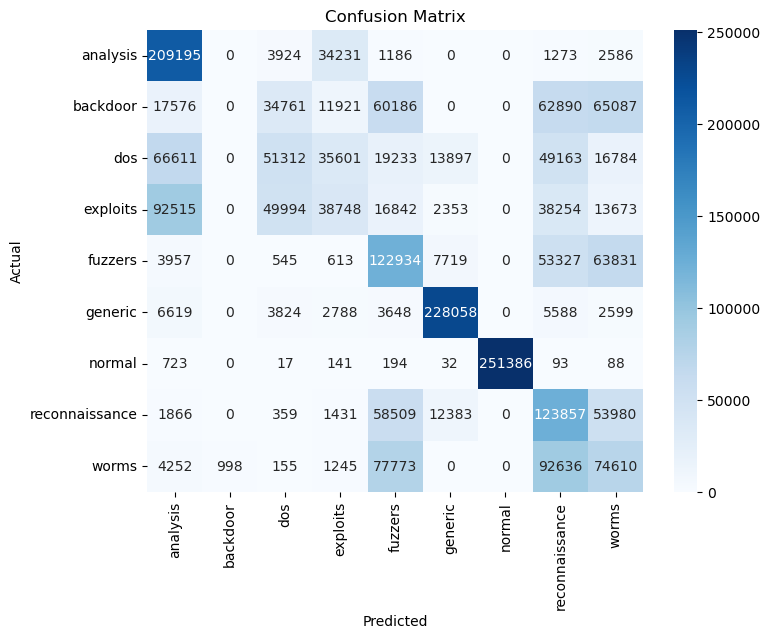

In [14]:
from sklearn.metrics import confusion_matrix
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_2, yticklabels=le_2)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [15]:
lr_multi_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

lr_multi_df

,Actual,Predicted
6537386,7,7
5694886,5,5
4977358,4,8
6178651,7,7
5495161,5,5
...,...,...
1085902,0,7
2539712,1,2
168458,6,6
4474023,4,4


# Decison Tree

In [16]:
# Train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)  # Added random_state for reproducibility
dt_model.fit(X_train, y_train)

# Predictions
dt_y_pred = dt_model.predict(X_test)
dt_y_pred_proba = dt_model.predict_proba(X_test)[:, 1]  # Probabilities for ROC curve (binary)

# Classification Report
dt_cls_report = classification_report(y_test, dt_y_pred, target_names=le_2)
print("Decision Tree Classification Report:\n", dt_cls_report)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_y_pred) * 100)

Decision Tree Classification Report:
                 precision    recall  f1-score   support

      analysis       0.96      0.97      0.97    252395
      backdoor       0.96      0.97      0.96    252421
           dos       0.88      0.86      0.87    252601
      exploits       0.87      0.83      0.85    252379
       fuzzers       0.92      0.90      0.91    252926
       generic       0.86      0.95      0.90    253124
        normal       1.00      1.00      1.00    252674
reconnaissance       0.91      0.87      0.89    252385
         worms       0.96      0.97      0.97    251669

      accuracy                           0.92   2272574
     macro avg       0.92      0.92      0.92   2272574
  weighted avg       0.92      0.92      0.92   2272574

Decision Tree Accuracy: 92.44504249366578


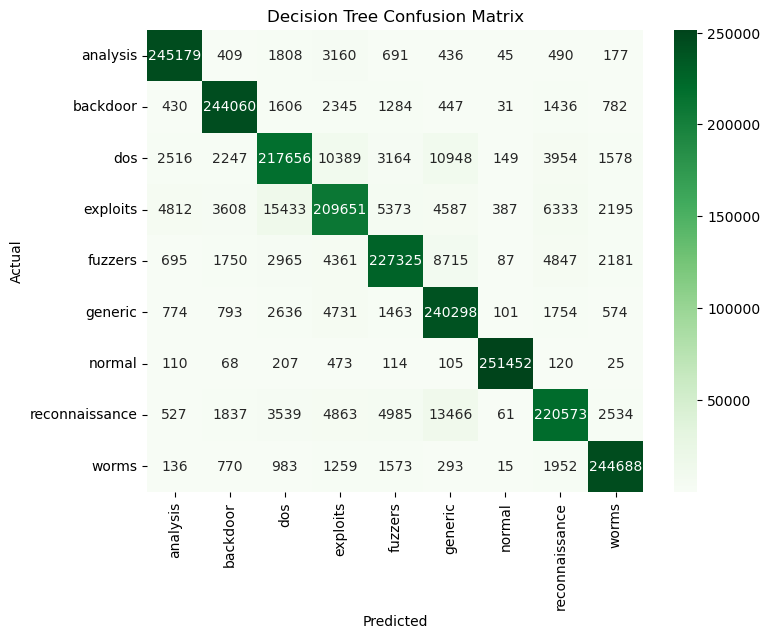

In [17]:
# Confusion Matrix
dt_cm = confusion_matrix(y_test, dt_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Greens', xticklabels=le_2, yticklabels=le_2)
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [19]:
dt_model_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

dt_model_df

,Actual,Predicted
6537386,7,7
5694886,5,5
4977358,4,8
6178651,7,7
5495161,5,5
...,...,...
1085902,0,7
2539712,1,2
168458,6,6
4474023,4,4


## KNN

In [20]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

 
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)
 
ylgb_pred = lgb_model.predict(X_test)

 
cls_report = classification_report(y_test, ylgb_pred, target_names=le_2)
print(cls_report)

# Print accuracy
print("Accuracy - ", accuracy_score(y_test, ylgb_pred) * 100)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.093173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1388
[LightGBM] [Info] Number of data points in the train set: 5302672, number of used features: 7
[LightGBM] [Info] Start training from score -2.197032
[LightGBM] [Info] Start training from score -2.197077
[LightGBM] [Info] Start training from score -2.197382
[LightGBM] [Info] Start training from score -2.197005
[LightGBM] [Info] Start training from score -2.197934
[LightGBM] [Info] Start training from score -2.198270
[LightGBM] [Info] Start training from score -2.197506
[LightGBM] [Info] Start training from score -2.197015
[LightGBM] [Info] Start training from score -2.195801
                precision    recall  f1-score   support

      analysis       0.80      0.97      0.88    252395
      backdoor       0.73      0.77      0.75  

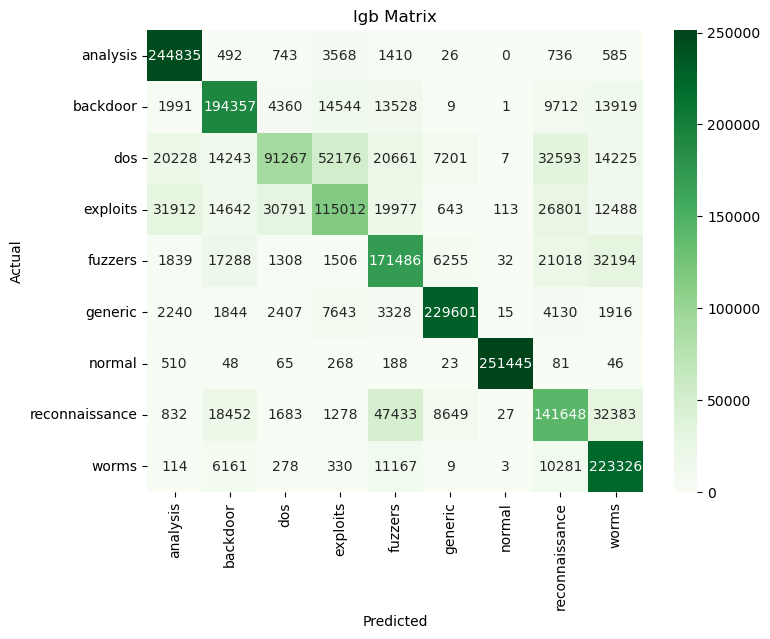

In [21]:
# Confusion Matrix
lgb_cm = confusion_matrix(y_test, ylgb_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(lgb_cm, annot=True, fmt='d', cmap='Greens', xticklabels=le_2, yticklabels=le_2)
plt.title('lgb Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [22]:
lgb_multi_df = pd.DataFrame({'Actual': y_test, 'Predicted': ylgb_pred})

lgb_multi_df

,Actual,Predicted
6537386,7,7
5694886,5,5
4977358,4,8
6178651,7,7
5495161,5,5
...,...,...
1085902,0,2
2539712,1,1
168458,6,6
4474023,4,4


## Naive Byes

In [25]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

# Create and fit the model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Make predictions
nb_pred = nb_model.predict(X_test)

# Classification report
cls_report_nb = classification_report(y_test, nb_pred, target_names=le_2)
print(cls_report_nb)

# Accuracy
print("Accuracy - ", accuracy_score(y_test, nb_pred) * 100)


                precision    recall  f1-score   support

      analysis       0.41      0.98      0.58    252395
      backdoor       0.18      0.81      0.29    252421
           dos       0.64      0.01      0.01    252601
      exploits       0.18      0.00      0.00    252379
       fuzzers       0.61      0.03      0.06    252926
       generic       0.86      0.90      0.88    253124
        normal       1.00      0.99      1.00    252674
reconnaissance       0.80      0.00      0.00    252385
         worms       0.87      0.00      0.00    251669

      accuracy                           0.41   2272574
     macro avg       0.62      0.41      0.31   2272574
  weighted avg       0.62      0.41      0.31   2272574

Accuracy -  41.38100673509422


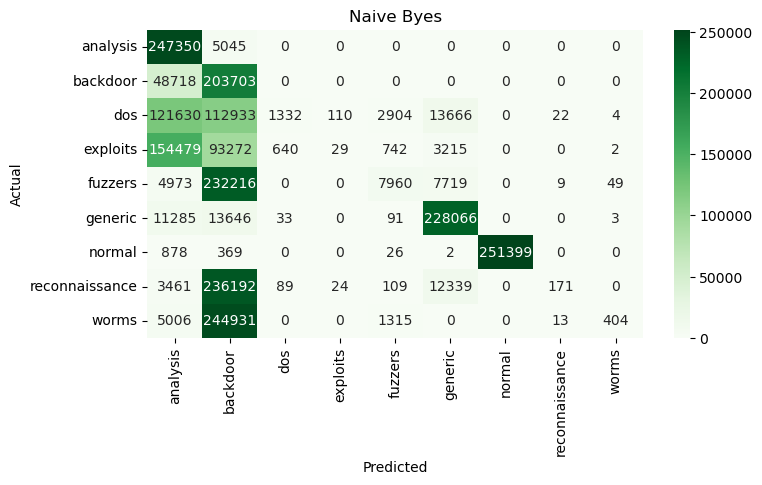

In [31]:
# Confusion Matrix
nb_cm = confusion_matrix(y_test, nb_pred)
plt.figure(figsize=(8, 4))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Greens', xticklabels=le_2, yticklabels=le_2)
plt.title('Naive Byes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [32]:
nb_multi_df = pd.DataFrame({'Actual': y_test, 'Predicted': nb_pred})

nb_multi_df

,Actual,Predicted
6537386,7,1
5694886,5,5
4977358,4,1
6178651,7,1
5495161,5,5
...,...,...
1085902,0,1
2539712,1,0
168458,6,6
4474023,4,1


In [28]:
!pip install catboost

   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.8/102.4 MB 5.6 MB/s eta 0:00:19
    --------------------------------------- 1.8/102.4 MB 5.6 MB/s eta 0:00:18
   - -------------------------------------- 2.9/102.4 MB 4.9 MB/s eta 0:00:21
   - -------------------------------------- 3.7/102.4 MB 4.4 MB/s eta 0:00:23
   - -------------------------------------- 4.2/102.4 MB 4.3 MB/s eta 0:00:23
   -- ------------------------------------- 5.2/102.4 MB 4.2 MB/s eta 0:00:23
   -- ------------------------------------- 6.0/102.4 MB 4.2 MB/s eta 0:00:23
   -- ------------------------------------- 6.8/102.4 MB 4.3 MB/s eta 0:00:23
   --- ------------------------------------ 7.9/102.4 MB 4.3 MB/s eta 0:00:22
   --- ------------------------------------ 8.9/102.4 MB 4.4 MB/s eta 0:00:22
   --- ------------------------------------ 10.0/102.4 MB 4.4 MB/s eta 0:00:21
   ---- ----------------------------------- 11.0/102.4 MB 4.5 MB/s eta

In [29]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score

catboost_model = CatBoostClassifier(iterations=100, random_state=42, verbose=0)
catboost_model.fit(X_train, y_train)

catboost_pred = catboost_model.predict(X_test)
print(classification_report(y_test, catboost_pred, target_names=le_2))
print("Accuracy - ", accuracy_score(y_test, catboost_pred) * 100)


                precision    recall  f1-score   support

      analysis       0.63      0.89      0.74    252395
      backdoor       0.56      0.63      0.59    252421
           dos       0.52      0.28      0.37    252601
      exploits       0.48      0.28      0.36    252379
       fuzzers       0.50      0.52      0.51    252926
       generic       0.88      0.90      0.89    253124
        normal       1.00      0.99      1.00    252674
reconnaissance       0.47      0.44      0.45    252385
         worms       0.56      0.74      0.63    251669

      accuracy                           0.63   2272574
     macro avg       0.62      0.63      0.62   2272574
  weighted avg       0.62      0.63      0.62   2272574

Accuracy -  63.126129226155015


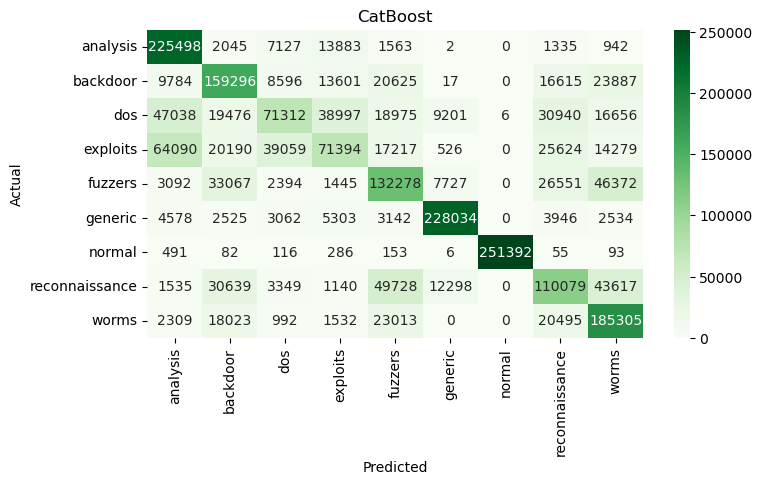

In [33]:
# Confusion Matrix
catb_cm = confusion_matrix(y_test, catboost_pred)
plt.figure(figsize=(8, 4))
sns.heatmap(catb_cm, annot=True, fmt='d', cmap='Greens', xticklabels=le_2, yticklabels=le_2)
plt.title('CatBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [35]:
 

# Ensure y_test is a 1D array
if isinstance(y_test, pd.DataFrame):
    y_test = y_test.values.ravel()
elif isinstance(y_test, np.ndarray) and y_test.ndim > 1:
    y_test = y_test.ravel()

# Ensure catboost_pred is a 1D array
if isinstance(catboost_pred, pd.DataFrame):
    catboost_pred = catboost_pred.values.ravel()
elif isinstance(catboost_pred, np.ndarray) and catboost_pred.ndim > 1:
    catboost_pred = catboost_pred.ravel()

# Now safely create the DataFrame
cat_boost_multi_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': catboost_pred
})

cat_boost_multi_df.head()


,Actual,Predicted
6537386,7,8
5694886,5,5
4977358,4,8
6178651,7,7
5495161,5,5


In [37]:
import joblib
joblib.dump(lr_multi, "logistic_model_multi.pkl")

['logistic_model_multi.pkl']

In [38]:
joblib.dump(dt_model, "Descion_tree_model_multi.pkl")

['Descion_tree_model_multi.pkl']

In [39]:
joblib.dump(lgb_model, "lgb_model_multi.pkl")

['lgb_model_multi.pkl']

In [40]:
joblib.dump(nb_model, "Naive_Byes_model_multi.pkl")

['Naive_Byes_model_multi.pkl']

In [41]:
joblib.dump(catboost_model, "cat_boost_model_multi.pkl")

['cat_boost_model_multi.pkl']

# Model Comparison

In [42]:
 
lr_model = joblib.load("logistic_model_multi.pkl")
dt_model = joblib.load("Descion_tree_model_multi.pkl")
lgb_model = joblib.load("lgb_model_multi.pkl")
nb_model = joblib.load("Naive_Byes_model_multi.pkl")
catboost_model = joblib.load("cat_boost_model_multi.pkl")

In [44]:
 
 
models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "LightGBM": lgb_model,
    "Naive Bayes": nb_model,
    "CatBoost": catboost_model
}

results = []

 
for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    f1 = report["macro avg"]["f1-score"]
    
    results.append({
        "Model": name,
        "Accuracy (%)": round(acc, 2),
        "Macro F1-Score": round(f1, 4)
    })

 
df = pd.DataFrame(results)
df["Rank"] = df["Macro F1-Score"].rank(ascending=False).astype(int)
df = df.sort_values(by="Rank")

print(df.reset_index(drop=True))


                 Model  Accuracy (%)  Macro F1-Score  Rank
0        Decision Tree         92.45          0.9242     1
1             LightGBM         73.18          0.7205     2
2             CatBoost         63.13          0.6154     3
3  Logistic Regression         48.41          0.4465     4
4          Naive Bayes         41.38          0.3141     5


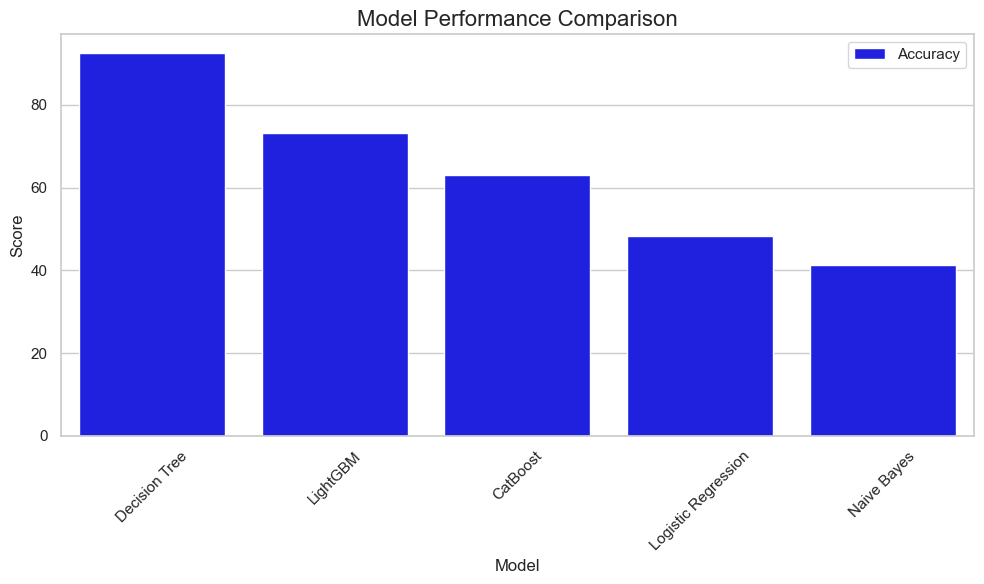

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(10, 6))
df_sorted = df.sort_values("Rank")

# Accuracy Bar
sns.barplot(data=df_sorted, x="Model", y="Accuracy (%)", color="blue", label="Accuracy")
 

# Aesthetics
plt.title("Model Performance Comparison", fontsize=16)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
